Pipeline de extração de features para o Protocolo de Estresse

Processa os sinais fisiológicos dos protocolos de estresse do artigo/dataset, cada protocolo gera um CSV separado com features das fases:

O fluxo por sujeito é

    Dados brutos (CSV por sensor)
        → Sincronização temporal (4Hz comum)
        → Rotulagem por protocolo (tags.csv → fases REST/STRESS)
        → Janelamento (60s janela, 30s passo, sobreposição 50%)
        → Extração de 49 features (EDA, HRV, ACC, BVP, HR)
        → CSV final com uma linha por janela

Dataset: WSD (Hongn et al., 2025) com 36 sujeitos utilizando o Empatica E4
Grupos: 
V1 (Sxx, 8 fases) 
V2 (Fxx, 7 fases)
"""

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import sys
PROJECT_ROOT = Path(__file__).resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore', message='Mean of empty slice')

from src.config import RAW_DATA_DIR, PROCESSED_DIR, WINDOW_SIZE, STEP_SIZE
from src.data_loader import load_subject_raw_data
from src.preprocessing import SignalPreprocessor
from src.labeling import get_session_start_time, load_tags, apply_labels
from src.feature_extraction import FeatureExtractor

As exclusões são baseadas no 'data_constraints.txt' do artigo/dataset:

- S02         -> arquivo corrompido / incompleto
- f07         -> sessão interrompida
- f14_a ou _b -> sujeito duplicado (duas tentativas)
- f17         -> dados faltantes

O script lista automaticamente as pastas de sujeitos dentro do diretório
do experimento. Cada pasta contém os CSVs por sensor
(ACC.csv, BVP.csv, EDA.csv, TEMP.csv, HR.csv, IBI.csv, tags.csv).

In [ ]:
EXPERIMENT = "STRESS"
EXPERIMENT_DIR = RAW_DATA_DIR / EXPERIMENT
#EXCLUSIONS = ['S02', 'f07', 'f14_a', 'f14_b', 'f17']
EXCLUSIONS = ['S02', 'f07', 'f13', 'f14_a', 'f14_b', 'f17']
subjects = sorted([p.name for p in EXPERIMENT_DIR.iterdir() if p.is_dir()])
subjects_valid = [s for s in subjects if s not in EXCLUSIONS]

print(f"Total: {len(subjects)}\nVálidos: {len(subjects_valid)}\nExcluídos: {EXCLUSIONS}")
print(f"Sujeitos: {subjects_valid}")

Total: 37
Válidos: 31
Excluídos: ['S02', 'f07', 'f13', 'f14_a', 'f14_b', 'f17']
Sujeitos: ['S01', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f08', 'f09', 'f10', 'f11', 'f12', 'f15', 'f16', 'f18']


Reimplementação do protocolo original (Hongn et al., 2025) que utilizou a segunda metade de cada um 
dos dois blocos de descanso para minimizar a influencia de qualquer efeito de estresse residual.

Baseline que é o primeiro bloco de repouso, é mantido integralmente e Blocos de repouso subsequentes com recuperação entre tarefas têm a 
primeira metade removida.

In [ ]:
def apply_inertia_cut(df_labeled):
    """Remove a primeira metade dos blocos de repouso pós-baseline."""
    df = df_labeled.copy()
    df['block_id'] = (df['label'].diff() != 0).cumsum()
    
    indices_to_keep = []
    rest_count = 0

    for block_id, group in df.groupby('block_id', sort=False):
        lbl = group['label'].iloc[0]
        
        if lbl == 0:  # Repouso
            rest_count += 1
            if rest_count > 1:  # Recuperação e não baseline
                cutoff = len(group) // 2
                indices_to_keep.extend(group.index[cutoff:])
            else:  # Baseline: mantém tudo
                indices_to_keep.extend(group.index)
        else:  # Stress: mantém tudo
            indices_to_keep.extend(group.index)
    
    df_cut = df.loc[indices_to_keep].copy()
    df_cut = df_cut.drop(columns=['block_id'])
    return df_cut

Processa um único sujeito para validar o pipeline antes do batch.
Serve como debug rápido que se acontecer algum erro aqui, não vale rodar os 32.

O fluxo de cada sujeito:
- load_subject_raw_data  -> lê os 6 CSVs e retorna dict {sensor: DataFrame}
- get_session_start_time -> lê timestamp absoluto do header do ACC.csv
- load_tags              -> converte timestamps das tags para segundos relativos
- synchronize_data       -> alinha todos os sensores para 4Hz (índice comum)
- apply_labels           -> marca label 0 (REST) ou 1 (STRESS) com base nas 
                            fases do protocolo (V1 ou V2, detectado pelo ID)
- extract_features       -> janela deslizante sobre os dados brutos, usando
                            df_labeled apenas para atribuir o label da janela
                            (moda dos labels dentro da janela)
- dropna                 -> remove janelas de borda com dados insuficientes

In [ ]:
TEST_SUBJECT = "f01"
subject_path = EXPERIMENT_DIR / TEST_SUBJECT
raw_data = load_subject_raw_data(subject_path)
print(f"Sensores carregados: {list(raw_data.keys())}")

session_start = get_session_start_time(subject_path)
tags_df = load_tags(subject_path, session_start)
print(f"Tags: {len(tags_df)} \nInício sessão: {session_start}")

preprocessor = SignalPreprocessor()
df_timeline = preprocessor.synchronize_data(raw_data)
#df_labeled = apply_labels(df_timeline, tags_df, subject_id=TEST_SUBJECT)
df_labeled = apply_labels(df_timeline, tags_df, subject_id=TEST_SUBJECT, protocol='STRESS')


counts = df_labeled['label'].value_counts()
print(f"\nRepouso: {counts.get(0, 0)} amostras \n Stress: {counts.get(1, 0)} amostras")

extractor = FeatureExtractor(window_size=WINDOW_SIZE, step_size=STEP_SIZE)
df_features = extractor.extract_features(raw_data, df_labeled)
df_features = df_features.dropna()

# Corte de inércia
print(f"Corte de Inércia, antes e depois do Corte\n")
print(f"Antes: {len(df_labeled)} amostras\n - Repouso(REST) = {sum(df_labeled['label']==0)}\n - Estresse(STRESS) = {sum(df_labeled['label']==1)}")
df_labeled = apply_inertia_cut(df_labeled)
print(f"Depois: {len(df_labeled)} amostras\n - Repouso(REST) = {sum(df_labeled['label']==0)}\n - Estresse(STRESS) = {sum(df_labeled['label']==1)}")

print(f"Features extraídas: {df_features.shape}")
print(f"Colunas: {list(df_features.columns)}")

Sensores carregados: ['ACC', 'BVP', 'EDA', 'TEMP', 'HR', 'IBI']
Tags: 9 
Início sessão: 2013-06-12 16:18:58+00:00

Repouso: 6257 amostras 
 Stress: 6716 amostras
Corte de Inércia, antes e depois do Corte

Antes: 12973 amostras
 - Repouso(REST) = 6257
 - Estresse(STRESS) = 6716
Depois: 10661 amostras
 - Repouso(REST) = 3945
 - Estresse(STRESS) = 6716
Features extraídas: (107, 51)
Colunas: ['window_id', 'label', 'bvp_mean', 'bvp_std', 'acc_x_mean', 'acc_x_std', 'acc_y_mean', 'acc_y_std', 'acc_z_mean', 'acc_z_std', 'acc_mean', 'acc_std', 'acc_ratio_up', 'acc_ratio_down', 'mean_raw_eda', 'std_raw_eda', 'mean_tonic_eda', 'std_tonic_eda', 'tonic_ratio_up', 'tonic_ratio_down', 'mean_phasic_eda', 'std_phasic_eda', 'peaks_density', 'scr_mean_amp', 'scr_mean_height', 'scr_mean_risetime', 'scr_mean_recoverytime', 'hr_mean', 'hr_std', 'hr_ratio_up', 'hr_ratio_down', 'max_ibi', 'min_ibi', 'mean_ibi', 'hr_mean_ibi', 'pnn20', 'pnn50', 'rmssd', 'sdnn', 'total_power', 'ratio', 'VLF_power', 'VLF_peak', 

Verifica visualmente se a extração faz sentido antes de rodar o batch.

Plota a média da atividade eletrodermica(EDA) bruta ao longo das janelas, colorido pelo label e é esperado ver valores mais altos (vermelho) nas fases de estresse e 
mais baixos (azul) no repouso.

Se o gráfico mostrar cores misturadas sem padrão, algo deu errado na rotulagem ou na sincronização.

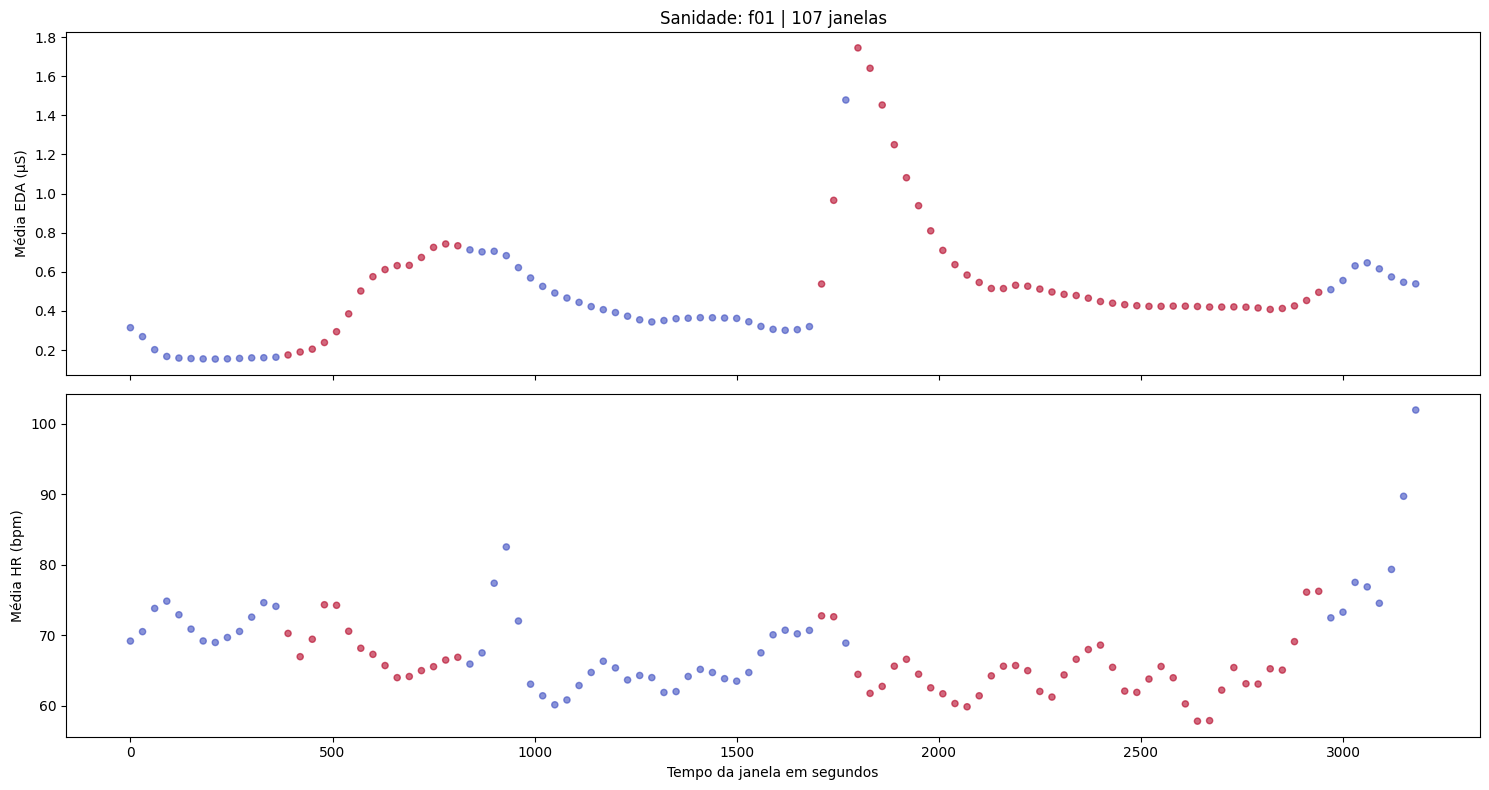

Labels no dataset de features:
label
1    56
0    51


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].scatter(df_features['window_id'], df_features['mean_raw_eda'],
                c=df_features['label'], cmap='coolwarm', alpha=0.6, s=20)
axes[0].set_ylabel("Média EDA (µS)")
axes[0].set_title(f"Sanidade: {TEST_SUBJECT} | {df_features.shape[0]} janelas")

axes[1].scatter(df_features['window_id'], df_features['hr_mean'],
                c=df_features['label'], cmap='coolwarm', alpha=0.6, s=20)
axes[1].set_ylabel("Média HR (bpm)")
axes[1].set_xlabel("Tempo da janela em segundos")

plt.tight_layout()
plt.show()

print(f"Labels no dataset de features:")
print(df_features['label'].value_counts().to_string())

Verifica se as features ['total_power', 'LF_power', 'HF_power', 'ratio'] foram processadas, elas são importantes para o experimento


In [ ]:
print(df_features[['total_power', 'LF_power', 'HF_power', 'ratio']].describe())

       total_power    LF_power    HF_power       ratio
count   107.000000  107.000000  107.000000  107.000000
mean    479.892383   84.592527  114.662676    0.801229
std     232.646925   63.007181   66.634982    0.647941
min     104.897803    6.909568   24.139330    0.111234
25%     305.246751   32.004761   67.507223    0.401225
50%     452.970967   78.636515   98.687900    0.550198
75%     661.171120  121.267514  147.924916    1.041002
max    1147.010512  297.062812  307.058889    3.603465


Roda o mesmo pipeline da celula anterior para todos os sujeitos válidos.

Para cada sujeito:
    - Carrega dados brutos
    - Sincroniza, rotula, extrai features
    - Adiciona coluna 'subject_id' para identificar a origem

Sujeitos que falharem são registrados em 'failed_subjects' para inspeção posterior, sem interromper o loop.

Saída: lista de DataFrames (um por sujeito), prontos para concatenação.

In [ ]:
all_features = []
failed_subjects = []

extractor = FeatureExtractor(window_size=WINDOW_SIZE, step_size=STEP_SIZE)
preprocessor = SignalPreprocessor()

for subj in tqdm(subjects_valid, desc="Processando STRESS"):
    try:
        subject_path = EXPERIMENT_DIR / subj

        raw_data = load_subject_raw_data(subject_path)
        if not raw_data:
            failed_subjects.append((subj, "Dados vazios"))
            continue

        session_start = get_session_start_time(subject_path)
        tags_df = load_tags(subject_path, session_start)
        df_timeline = preprocessor.synchronize_data(raw_data)
        #df_labeled = apply_labels(df_timeline, tags_df, subject_id=subj)
        df_labeled = apply_labels(df_timeline, tags_df, subject_id=subj, protocol='STRESS')
        df_labeled = apply_inertia_cut(df_labeled)


        # Extrai features
        df_feats = extractor.extract_features(raw_data, df_labeled)
        df_feats['subject_id'] = subj
        df_feats = df_feats.dropna()

        if not df_feats.empty:
            all_features.append(df_feats)
            print(f"  {subj}: {df_feats.shape[0]} janelas | REST={sum(df_feats['label']==0)} STRESS={sum(df_feats['label']==1)}")

    except Exception as e:
        print(f"  ERRO {subj}: {e}")
        failed_subjects.append((subj, str(e)))

print(f"\nProcessados: {len(all_features)} | Falhas: {len(failed_subjects)}")
if failed_subjects:
    print("Falhas:", failed_subjects)

Processando STRESS:   3%|▎         | 1/31 [00:06<03:15,  6.50s/it]

  S01: 59 janelas | REST=29 STRESS=30


Processando STRESS:   6%|▋         | 2/31 [00:09<02:10,  4.49s/it]

  S03: 50 janelas | REST=23 STRESS=27


Processando STRESS:  10%|▉         | 3/31 [00:13<02:01,  4.33s/it]

...

  f15: 124 janelas | REST=88 STRESS=36


Processando STRESS:  97%|█████████▋| 30/31 [03:05<00:10, 10.35s/it]

  f16: 89 janelas | REST=54 STRESS=35


Processando STRESS: 100%|██████████| 31/31 [03:16<00:00,  6.32s/it]

  f18: 88 janelas | REST=54 STRESS=34

Processados: 31 | Falhas: 0


Concatena os DataFrames de todos os sujeitos em um dataset único.

Organiza as colunas com metadados (subject_id, label) à esquerda e features à direita. Salva como CSV em PROCESSED_DIR. Este CSV é a entrada direta para o script de modelagem.

In [ ]:
df_stress = pd.concat(all_features, ignore_index=True)

meta_cols = ['subject_id', 'window_id', 'label']
feature_cols = [c for c in df_stress.columns if c not in meta_cols]
df_stress = df_stress[meta_cols + feature_cols]

print(f"Dataset final: {df_stress.shape}")
print(f"Sujeitos: {df_stress['subject_id'].nunique()}")
print(f"\nDistribuição de labels:")
print(df_stress['label'].value_counts().to_string())
print(f"\nJanelas por sujeito:")
print(df_stress.groupby('subject_id')['label'].count().to_string())

output_path = PROCESSED_DIR / "dataset_stress.csv"
df_stress.to_csv(output_path, index=False)
print(f"\nSalvo em: {output_path}")

Dataset final: (2210, 52)
Sujeitos: 31

Distribuição de labels:
label
0    1161
1    1049

Janelas por sujeito:
subject_id
S01     59
S03     50
S04     48
S05     50
S06     47
S07     41
S08     43
S09     45
S10     51
S11     39
S12     50
S13     52
S14     54
S15     53
S16     48
S17     50
S18     52
f01     93
f02     84
f03     98
f04    100
f05    135
f06     87
f08     85
f09     90
f10     73
f11     89
f12    143
f15    124
f16     89
f18     88

Salvo em: C:\DEV\mestrado\WSD\experiments\processed\dataset_stress.csv
